--- Regression Metrics ---
R2: 0.9893
RMSE: 13428.89

--- Other Metrics ---
Accuracy: 0.9688
Precision: 0.9412
Recall: 1.0000
F1-Score: 0.9697


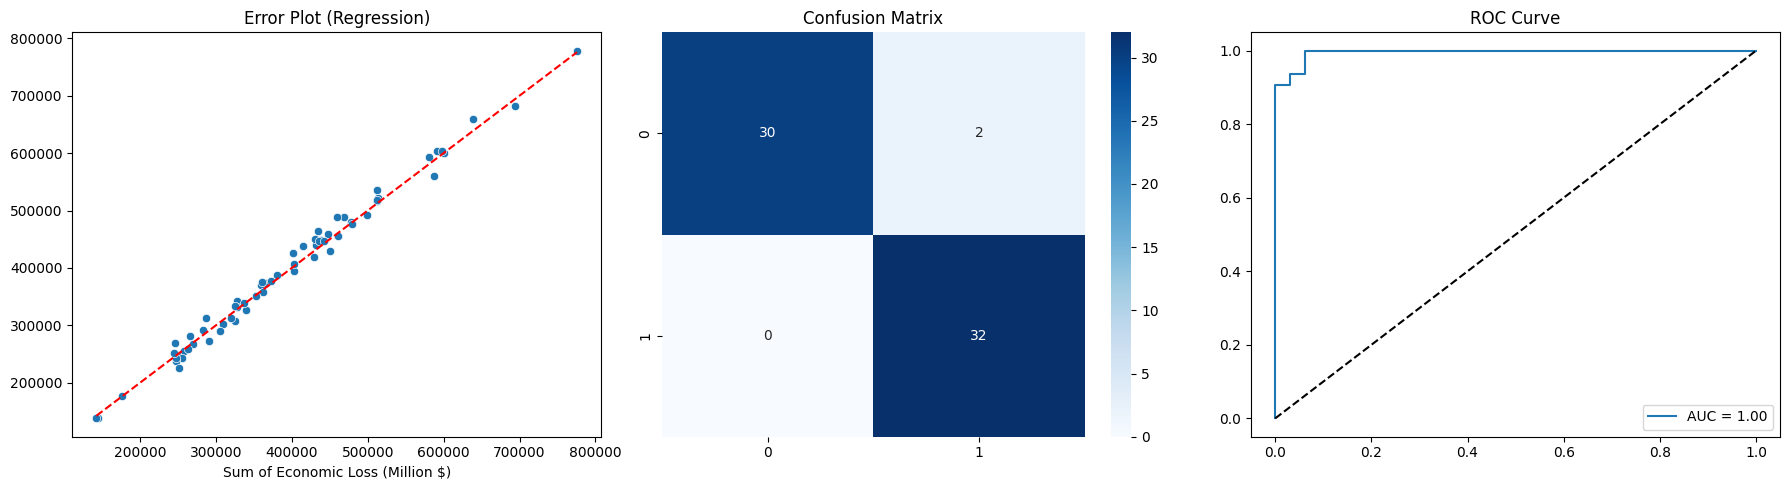

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (mean_absolute_error, r2_score, mean_squared_error,
                             accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_curve, auc)
from sklearn.preprocessing import StandardScaler

file_name = 'Linear Regression Cleaned Data.csv'
df = pd.read_csv(file_name)

# 2. DATA PREPARATION
X = df.drop(['Sum of Economic Loss (Million $)', 'Food Category', 'Year Category'], axis=1)
X = pd.get_dummies(X, columns=['Country'], drop_first=True)

y_reg = df['Sum of Economic Loss (Million $)']
y_clf = (y_reg > y_reg.median()).astype(int) # For Accuracy/ROC metrics

# 3. SPLIT & SCALE
X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)
_, _, y_train_clf, y_test_clf = train_test_split(X, y_clf, test_size=0.2, random_state=42)

#Logistic Regression ve RMSE
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. MODEL TRAINING
# Regression
reg_model = LinearRegression()
reg_model.fit(X_train_scaled, y_train_reg)

# Evaluating the metrics (Acc, Prec, Rec, F1, ROC)
clf_model = LogisticRegression()
clf_model.fit(X_train_scaled, y_train_clf)

# 5. EVALUATION
y_pred_reg = reg_model.predict(X_test_scaled)
y_pred_clf = clf_model.predict(X_test_scaled)
y_prob_clf = clf_model.predict_proba(X_test_scaled)[:, 1]

print("--- Regression Metrics ---")
print(f"R2: {r2_score(y_test_reg, y_pred_reg):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_reg)):.2f}")

print("\n--- Other Metrics ---")
print(f"Accuracy: {accuracy_score(y_test_clf, y_pred_clf):.4f}")
print(f"Precision: {precision_score(y_test_clf, y_pred_clf):.4f}")
print(f"Recall: {recall_score(y_test_clf, y_pred_clf):.4f}")
print(f"F1-Score: {f1_score(y_test_clf, y_pred_clf):.4f}")

# 6. VISUALIZATIONS
plt.figure(figsize=(18, 5))

# Error Plot
plt.subplot(1, 3, 1)
sns.scatterplot(x=y_test_reg, y=y_pred_reg)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--')
plt.title('Error Plot (Regression)')

# Confusion Matrix
plt.subplot(1, 3, 2)
sns.heatmap(confusion_matrix(y_test_clf, y_pred_clf), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')

# ROC Curve
plt.subplot(1, 3, 3)
fpr, tpr, _ = roc_curve(y_test_clf, y_prob_clf)
plt.plot(fpr, tpr, label=f'AUC = {auc(fpr, tpr):.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve')
plt.legend()

plt.tight_layout()
plt.show()